In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROCESSED_DIR = "../data/processed"
MODEL_DATA_PATH = os.path.join(PROCESSED_DIR, "corridor_model_pre.csv")

FIGURES_DIR = "../reports/figures"
MODELS_DIR = "../reports/models"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

In [3]:
# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def save_show(fig_name: str):
    """
    Save the current matplotlib figure and display it.
    """
    output_path = os.path.join(FIGURES_DIR, fig_name)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()
    print(f"Saved: {output_path}")


def evaluate_classifier(y_true, y_pred, y_proba):
    """
    Return a dictionary of common binary classification metrics.
    """
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }


def print_model_report(model_name: str, y_true, y_pred, y_proba):
    """
    Print model metrics and classification report.
    """
    metrics = evaluate_classifier(y_true, y_pred, y_proba)

    print(f"\n{'=' * 60}")
    print(f"{model_name} PERFORMANCE")
    print(f"{'=' * 60}")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return metrics

In [4]:
# ============================================================
# 3. LOAD MODELING DATA
# ============================================================
# This is the pre-event dataset, which avoids leakage.
# It only contains features that are available before the
# final delay outcome happens.

df = pd.read_csv(MODEL_DATA_PATH, parse_dates=["depart_time"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 16)


,shipment_id,truck_id,depart_time,goods_category,weight_kg,declared_value_usd,fuel_price_usd_per_litre,rainfall_indicator,depart_month,depart_day_of_week_num,depart_hour,is_weekend,is_high_value,is_heavy,rolling_delay_rate_30,is_delayed
0,SHP00823,TRK600,2024-01-01 03:00:00,Fuel,28351.50,34054.16,1.38,1,1,0,3,0,0,0,NaN,0
1,SHP00640,TRK331,2024-01-01 12:00:00,Machinery,10666.48,12530.05,1.60,1,1,0,12,0,0,0,NaN,0
2,SHP00639,TRK688,2024-01-01 16:00:00,Machinery,17593.27,24469.33,1.49,0,1,0,16,0,0,0,NaN,1
3,SHP00842,TRK761,2024-01-01 19:00:00,Pharmaceuticals,3041.22,3616.17,1.45,1,1,0,19,0,0,0,NaN,0
4,SHP00652,TRK182,2024-01-02 00:00:00,Pharmaceuticals,5562.38,5554.66,1.45,1,1,1,0,0,0,0,NaN,1


In [5]:
# ============================================================
# 4. QUICK DATA CHECKS
# ============================================================
df.info()

# Missing values by column
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary

# Target distribution
target_distribution = df["is_delayed"].value_counts(normalize=True) * 100
print("Target distribution (%):")
print(target_distribution)

# Delay rate
delay_rate = df["is_delayed"].mean() * 100
print(f"Overall delay rate: {delay_rate:.2f}%")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   shipment_id               1000 non-null   object        
 1   truck_id                  1000 non-null   object        
 2   depart_time               1000 non-null   datetime64[ns]
 3   goods_category            1000 non-null   object        
 4   weight_kg                 1000 non-null   float64       
 5   declared_value_usd        1000 non-null   float64       
 6   fuel_price_usd_per_litre  1000 non-null   float64       
 7   rainfall_indicator        1000 non-null   int64         
 8   depart_month              1000 non-null   int64         
 9   depart_day_of_week_num    1000 non-null   int64         
 10  depart_hour               1000 non-null   int64         
 11  is_weekend                1000 non-null   int64         
 12  is_high_value        

In [6]:
# ============================================================
# 5. TIME-BASED TRAIN / TEST SPLIT
# ============================================================
# This is more realistic than a random split because it mimics
# real deployment:
#   Train on past shipments -> Predict future shipments

df = df.sort_values("depart_time").reset_index(drop=True)

split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain date range:")
print(train_df["depart_time"].min(), "to", train_df["depart_time"].max())

print("\nTest date range:")
print(test_df["depart_time"].min(), "to", test_df["depart_time"].max())

Train shape: (800, 16)
Test shape: (200, 16)

Train date range:
2024-01-01 03:00:00 to 2024-05-24 08:00:00

Test date range:
2024-05-24 09:00:00 to 2024-06-29 21:00:00


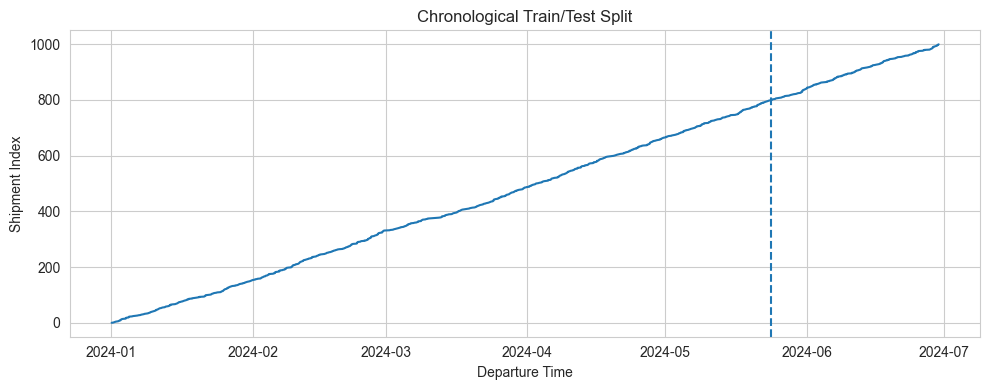

Saved: ../reports/figures\21_time_based_split.png


In [7]:
# ============================================================
# 6. VISUALIZE TRAIN / TEST TIME SPLIT
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(df["depart_time"], np.arange(len(df)))
plt.axvline(
    x=train_df["depart_time"].max(),
    linestyle="--"
)
plt.title("Chronological Train/Test Split")
plt.xlabel("Departure Time")
plt.ylabel("Shipment Index")
save_show("21_time_based_split.png")

In [8]:
# ============================================================
# 7. DEFINE FEATURES AND TARGET
# ============================================================
TARGET_COL = "is_delayed"
ID_COLS = ["shipment_id", "truck_id"]
TIME_COLS_TO_EXCLUDE = ["depart_time"]  # exclude raw datetime for baseline modeling

# Training target
y_train = train_df[TARGET_COL].astype(int)
y_test = test_df[TARGET_COL].astype(int)

# Feature matrices
X_train = train_df.drop(columns=[TARGET_COL] + ID_COLS + TIME_COLS_TO_EXCLUDE)
X_test = test_df.drop(columns=[TARGET_COL] + ID_COLS + TIME_COLS_TO_EXCLUDE)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (800, 12)
X_test shape: (200, 12)


In [9]:
# ============================================================
# 8. IDENTIFY FEATURE TYPES
# ============================================================
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['weight_kg', 'declared_value_usd', 'fuel_price_usd_per_litre', 'rainfall_indicator', 'depart_month', 'depart_day_of_week_num', 'depart_hour', 'is_weekend', 'is_high_value', 'is_heavy', 'rolling_delay_rate_30']

Categorical features:
['goods_category']


In [10]:
# ============================================================
# 9. PREPROCESSING
# ============================================================
# Numeric:
#   - fill missing values with median
#
# Categorical:
#   - fill missing values with most frequent
#   - one-hot encode
#
# ColumnTransformer applies the correct preprocessing to each type.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [11]:
# ============================================================
# 10. BASELINE MODEL: LOGISTIC REGRESSION
# ============================================================
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg_pipeline.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg_pipeline.predict(X_test)
y_proba_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
metrics_log = print_model_report(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=y_pred_log,
    y_proba=y_proba_log
)


Logistic Regression PERFORMANCE
accuracy: 0.6800
precision: 0.1404
recall: 0.3478
f1_score: 0.2000
roc_auc: 0.5316

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       177
           1       0.14      0.35      0.20        23

    accuracy                           0.68       200
   macro avg       0.52      0.54      0.50       200
weighted avg       0.81      0.68      0.73       200



c:\Users\Public\Projects\trade-corridor-analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# ============================================================
# 11. TREE MODEL: RANDOM FOREST
# ============================================================
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
metrics_rf = print_model_report(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf
)


Random Forest PERFORMANCE
accuracy: 0.8850
precision: 0.0000
recall: 0.0000
f1_score: 0.0000
roc_auc: 0.5303

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       177
           1       0.00      0.00      0.00        23

    accuracy                           0.89       200
   macro avg       0.44      0.50      0.47       200
weighted avg       0.78      0.89      0.83       200



In [13]:
# ============================================================
# 12. MODEL COMPARISON
# ============================================================
results_df = pd.DataFrame(
    [metrics_log, metrics_rf],
    index=["Logistic Regression", "Random Forest"]
).sort_values("f1_score", ascending=False)

results_df

,accuracy,precision,recall,f1_score,roc_auc
Logistic Regression,0.680,0.140351,0.347826,0.2,0.531565
Random Forest,0.885,0.000000,0.000000,0.0,0.530337


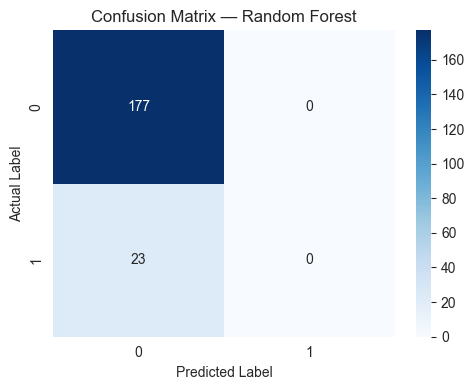

Saved: ../reports/figures\22_confusion_matrix_random_forest.png


In [14]:
# ============================================================
# 13. CONFUSION MATRIX (BEST MODEL EXAMPLE: RANDOM FOREST)
# ============================================================
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
save_show("22_confusion_matrix_random_forest.png")

<Figure size 700x500 with 0 Axes>

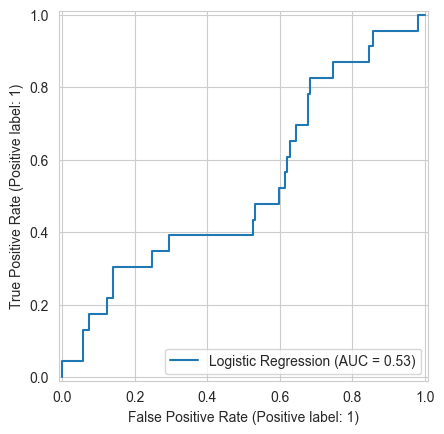

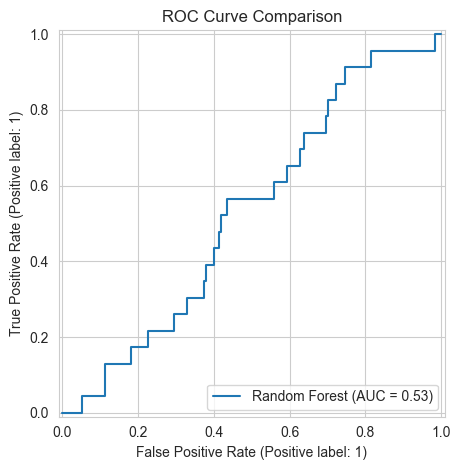

Saved: ../reports/figures\23_roc_curve_comparison.png


In [15]:
# ============================================================
# 14. ROC CURVE COMPARISON
# ============================================================
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest")
plt.title("ROC Curve Comparison")
save_show("23_roc_curve_comparison.png")

<Figure size 700x500 with 0 Axes>

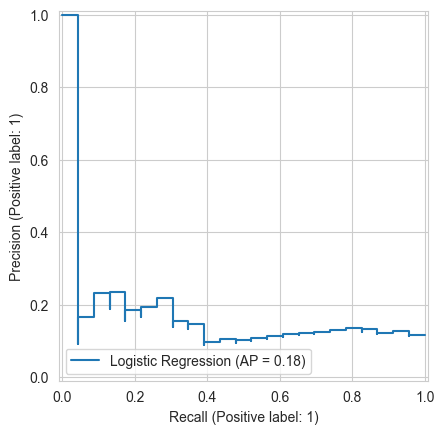

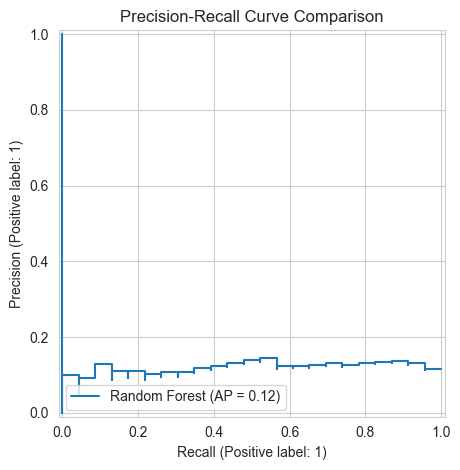

Saved: ../reports/figures\24_precision_recall_curve_comparison.png


In [16]:
# ============================================================
# 15. PRECISION-RECALL CURVE COMPARISON
# ============================================================
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_log, name="Logistic Regression")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest")
plt.title("Precision-Recall Curve Comparison")
save_show("24_precision_recall_curve_comparison.png")

In [17]:
# ============================================================
# 16. FEATURE IMPORTANCE
# ============================================================
# To get feature importance from a pipeline with one-hot encoding,
# we must reconstruct the transformed feature names.

rf_model = rf_pipeline.named_steps["classifier"]

ohe = rf_pipeline.named_steps["preprocessor"] \
    .named_transformers_["categorical"] \
    .named_steps["onehot"]

encoded_categorical_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, encoded_categorical_names])

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
2,fuel_price_usd_per_litre,0.150435
10,rolling_delay_rate_30,0.149722
0,weight_kg,0.147600
1,declared_value_usd,0.147121
6,depart_hour,0.116425
5,depart_day_of_week_num,0.076685
4,depart_month,0.064284
3,rainfall_indicator,0.024782
7,is_weekend,0.017587
15,goods_category_Machinery,0.016512


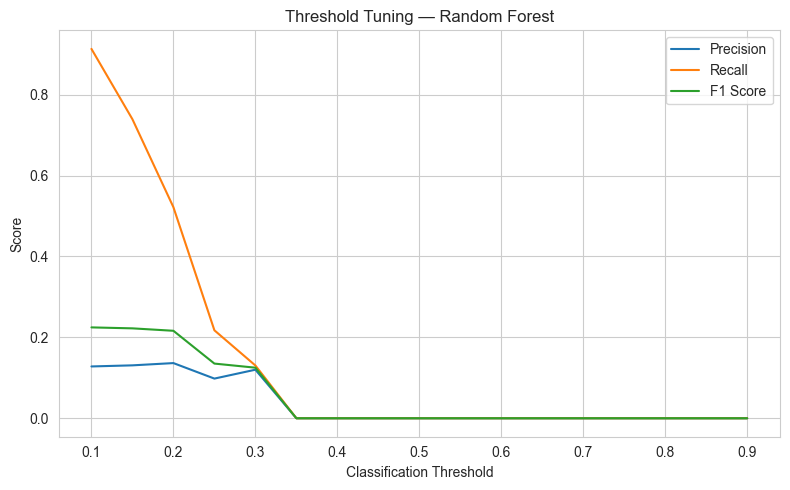

Saved: ../reports/figures\26_threshold_tuning_random_forest.png


In [18]:
# ============================================================
# 17. THRESHOLD TUNING
# ============================================================
# Default classification threshold is 0.50.
# Here we test multiple thresholds to see the tradeoff between
# precision, recall, and F1.

thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1 Score")
plt.title("Threshold Tuning — Random Forest")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
save_show("26_threshold_tuning_random_forest.png")

In [19]:
# ============================================================
# 18. SELECT BEST MODEL
# ============================================================
# You can choose based on F1, ROC AUC, or business preference.
# Example:
# - Use F1 if you want balance
# - Use Recall if missing delays is costly
# - Use Precision if false alarms are costly

best_model_name = results_df.index[1]
print("Best model based on F1 score:", best_model_name)

Best model based on F1 score: Random Forest


In [20]:
# ============================================================
# 19. SAVE BEST MODEL
# ============================================================
if best_model_name == "Random Forest":
    best_model = rf_pipeline
    best_model_file = "delay_risk_model_random_forest.joblib"
else:
    best_model = log_reg_pipeline
    best_model_file = "delay_risk_model_logistic_regression.joblib"

best_model_path = os.path.join(MODELS_DIR, best_model_file)
joblib.dump(best_model, best_model_path)

print("Saved best model to:")
print(best_model_path)

Saved best model to:
../reports/models\delay_risk_model_random_forest.joblib


In [21]:
# ============================================================
# 20. CREATE A SCORING TABLE
# ============================================================
scored_test_df = test_df.copy()
scored_test_df["predicted_delay_probability"] = y_proba_rf
scored_test_df["predicted_delay_label"] = y_pred_rf

scored_test_df[[
    "shipment_id",
    "depart_time",
    "goods_category",
    "fuel_price_usd_per_litre",
    "rainfall_indicator",
    "predicted_delay_probability",
    "predicted_delay_label",
    "is_delayed"
]].head(10)

# Top 10 highest-risk shipments
high_risk_shipments = scored_test_df.sort_values(
    "predicted_delay_probability",
    ascending=False
).head(10)

high_risk_shipments[[
    "shipment_id",
    "depart_time",
    "goods_category",
    "predicted_delay_probability",
    "predicted_delay_label",
    "is_delayed"
]]

,shipment_id,depart_time,goods_category,predicted_delay_probability,predicted_delay_label,is_delayed
833,SHP00773,2024-05-31 03:00:00,Fuel,0.446284,0,0
988,SHP00790,2024-06-28 14:00:00,Textiles,0.419855,0,0
818,SHP00145,2024-05-28 17:00:00,Fuel,0.419063,0,0
973,SHP00670,2024-06-25 10:00:00,Textiles,0.406668,0,0
898,SHP00255,2024-06-11 08:00:00,Electronics,0.394995,0,0
875,SHP00632,2024-06-07 02:00:00,Textiles,0.381733,0,0
974,SHP00914,2024-06-25 10:00:00,Fuel,0.380170,0,0
899,SHP00267,2024-06-11 09:00:00,Pharmaceuticals,0.379621,0,0
805,SHP00242,2024-05-25 07:00:00,Pharmaceuticals,0.376361,0,0
926,SHP00350,2024-06-16 05:00:00,Fuel,0.345285,0,1


In [22]:
# ============================================================
# 21. SAVE SCORED TEST DATA
# ============================================================
scored_output_path = os.path.join(PROCESSED_DIR, "corridor_test_scored.csv")
scored_test_df.to_csv(scored_output_path, index=False)

print("Saved scored test dataset to:")
print(scored_output_path)

Saved scored test dataset to:
../data/processed\corridor_test_scored.csv
